In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

**Carregamento da Base de Dados**

O dataset `school_performance.csv` foi carregado utilizando `pandas`.

Em seguida:
- verificamos os nomes das colunas
- visualizamos as primeiras linhas da base

In [ ]:
dados = pd.read_csv('school perfomance.csv', sep=';')

In [ ]:
print(dados.columns)
print(dados.head())

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6 

In [ ]:
dados.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Definição da Variável Alvo**

Foi criada uma variável chamada `y`, representando o risco acadêmico do aluno com base na nota final (`G3`).

Critério adotado:
- Nota menor que 10 = baixo desempenho
- Nota maior ou igual a 10 e menor ou igual a 14 = médio desempenho
- Nota maior ou igual a 15 e menor ou igual a 20 = ótimo desempenho

Essa transformação simplifica a análise em 3 categorias.

In [ ]:
def classificar_nota(nota):
    if nota < 10:
        return 'Baixo'
    elif nota < 15:
        return 'Médio'
    else:
        return 'Alto'

dados['categoria'] = dados['G3'].apply(classificar_nota)

**Distribuição da Variável Alvo**

Nesta etapa, verificamos a quantidade de alunos aprovados e em risco acadêmico.

Isso ajuda a entender:
- o equilíbrio das classes
- a distribuição dos resultados acadêmicos na base

In [ ]:
print(dados['categoria'].value_counts())

categoria
Médio    192
Baixo    130
Alto      73
Name: count, dtype: int64


**Seleção das Características dos Alunos**

Foram selecionadas variáveis numéricas relevantes para medir similaridade entre alunos:

- notas (`G1`, `G2`, `G3`)
- tempo de estudo (`studytime`)
- faltas (`absences`)
- reprovações (`failures`)
- vida social e hábitos (`goout`, `freetime`, `Walc`, `Dalc`)

Essas características serão usadas para construir a rede de similaridade.

In [ ]:
#escolher atributos numericos semelhantes
features = dados[['G1','G2',
                  'studytime',
                  'failures',
                  'absences',
                  'goout',
                  'freetime',
                  'Walc',
                  'Dalc']]

**Normalização dos Dados**

As variáveis possuem escalas diferentes.

Por exemplo:
- faltas podem chegar a valores altos
- consumo de álcool varia apenas entre 1 e 5

Por isso, aplicamos a padronização com `StandardScaler`, garantindo que todas as variáveis tenham o mesmo peso na análise de similaridade.

In [ ]:
#as variavies tem escalas diferentes, normalizar para terem o mesmo peso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)

**Cálculo da Similaridade entre Alunos**

Utilizamos a similaridade do cosseno (`cosine similarity`) para medir o quão parecidos os alunos são entre si.

A similaridade varia entre:
- `1` → alunos muito semelhantes
- `0` → sem relação
- valores negativos → perfis diferentes

O resultado é uma matriz onde cada posição representa a similaridade entre dois alunos.

In [ ]:
#medindo o quão parecidos são os alunos
from sklearn.metrics.pairwise import cosine_similarity

similaridade = cosine_similarity(X)


In [ ]:
print(similaridade)


[[ 1.          0.93303383 -0.01829231 ... -0.1760905  -0.47627549
   0.15605993]
 [ 0.93303383  1.          0.06935389 ... -0.14465832 -0.27036578
   0.18618499]
 [-0.01829231  0.06935389  1.         ...  0.76792896  0.08839738
   0.12888575]
 ...
 [-0.1760905  -0.14465832  0.76792896 ...  1.          0.32767647
   0.12227473]
 [-0.47627549 -0.27036578  0.08839738 ...  0.32767647  1.
   0.49080411]
 [ 0.15605993  0.18618499  0.12888575 ...  0.12227473  0.49080411
   1.        ]]


##Criação dos Grafos

**Construção do Grafo**

Foi criado um grafo utilizando a biblioteca `NetworkX`.

Na rede:
- cada aluno representa um nó
- conexões representam semelhança entre alunos

Isso permite transformar os dados em uma estrutura de rede para análise visual e relacional.

In [ ]:
G = nx.Graph()

#adicionar nó
for i in range(len(dados)):
  G.add_node(i)

#cada aluno vira um nó

**Criação das Conexões entre os Alunos**

Definimos um limite de similaridade (`threshold = 0.75`).

Se dois alunos possuem similaridade maior que 0.75:
- uma aresta é criada entre eles

Assim, somente alunos com perfis realmente parecidos ficam conectados na rede.

In [ ]:
for i in range(len(dados)):
    G.add_node(i)

In [ ]:
threshold = 0.75

for i in range(len(dados)):
    for j in range(i+1, len(dados)):
        if similaridade[i][j] > threshold:
            G.add_edge(i, j, weight=similaridade[i][j])

**Informações da Rede**

Nesta etapa, exibimos:
- quantidade de nós (alunos)
- quantidade de arestas (conexões)

Essas métricas ajudam a entender:
- o tamanho da rede
- o nível de conectividade entre os estudantes

In [ ]:
print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

Nós: 395
Arestas: 2293


**Detecção de Comunidades**

O algoritmos de detecção de comunidades identificou diferentes grupos naturais de alunos dentro da rede.

Esses grupos representam estudantes com características semelhantes em relação a:
* desempenho acadêmico
* tempo de estudo
* faltas
* comportamento social

As maiores comunidades representam os padrões  mais comuns presentes no conjunto de dados.

In [ ]:
#agrupa automaticamente os alunos que são semelhantes
from networkx.algorithms.community import greedy_modularity_communities

comunidades = list(greedy_modularity_communities(G))

In [ ]:
for i, comunidade in enumerate(comunidades):
    print(f'Comunidade {i}: {len(comunidade)} alunos')

Comunidade 0: 107 alunos
Comunidade 1: 103 alunos
Comunidade 2: 94 alunos
Comunidade 3: 29 alunos
Comunidade 4: 29 alunos
Comunidade 5: 17 alunos
Comunidade 6: 12 alunos
Comunidade 7: 1 alunos
Comunidade 8: 1 alunos
Comunidade 9: 1 alunos
Comunidade 10: 1 alunos


In [ ]:
#alunos isolados - possível risco
isolados = list(nx.isolates(G))
print(isolados)

[130, 267, 309, 340]


**Visualização do Grafo**

O grafo foi desenhado utilizando `matplotlib`.

Interpretação:
- nós próximos representam alunos com características semelhantes
- grupos mais densos indicam comunidades de alunos parecidos
- nós isolados representam alunos com perfil diferente da maioria

Essa visualização permite identificar padrões de comportamento e desempenho acadêmico.

In [ ]:
cores = []

for node in G.nodes():
    categoria = dados.loc[node, 'categoria']

    if categoria == 'Baixo':
        cores.append('red')
    elif categoria == 'Médio':
        cores.append('yellow')
    else:
        cores.append('green')

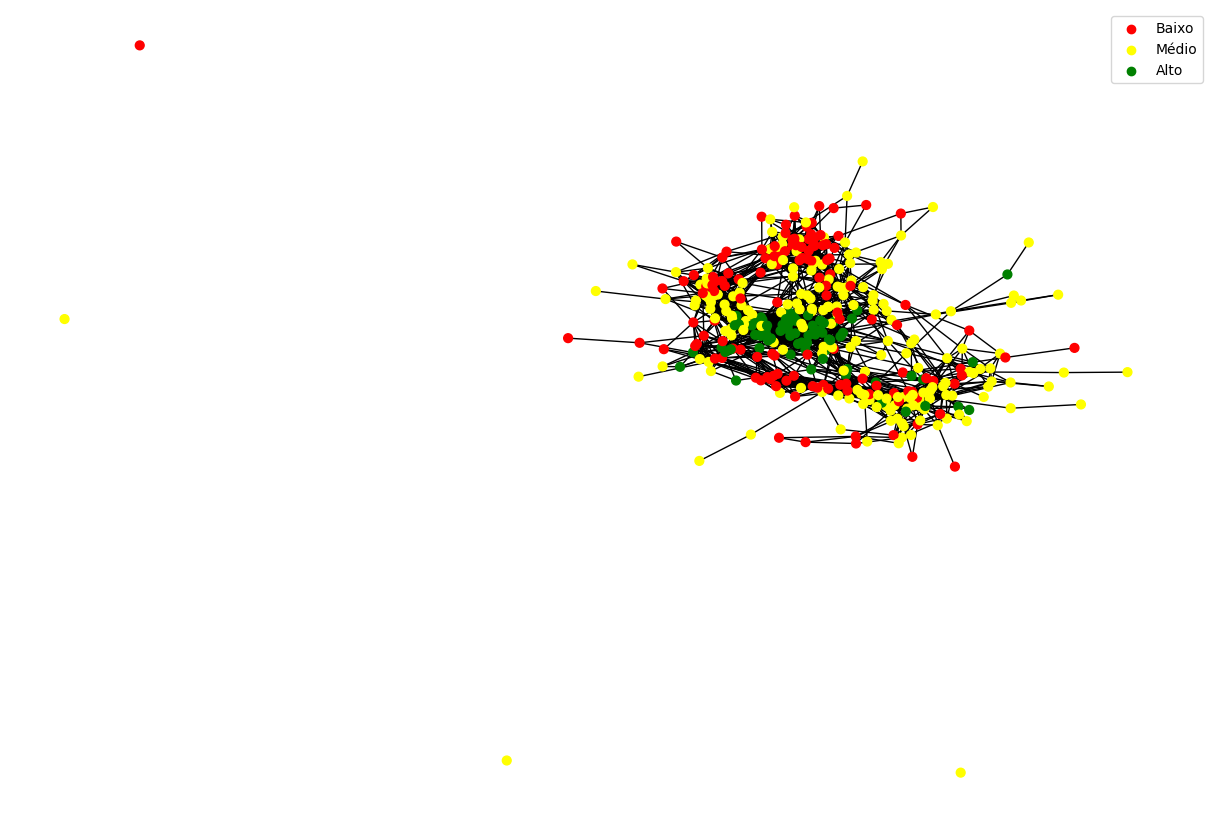

In [ ]:
plt.figure(figsize=(12,8))

nx.draw(
    G,
    node_color=cores,
    node_size=40,
    with_labels=False
)

plt.scatter([], [], c='red', label='Baixo')
plt.scatter([], [], c='yellow', label='Médio')
plt.scatter([], [], c='green', label='Alto')

plt.legend()
plt.show()

**Interpretação do Grafo 1**

Na visualização da rede, cada nó representa um aluno e cada conexão representa alta similaridade entre seus perfis acadêmicos e comportamentais.

As cores representam as categorias de desempenho acadêmico:

- **Verde:** alto desempenho  
- **Amarelo:** desempenho médio  
- **Vermelho:** baixo desempenho  

Observou-se a formação de comunidades com maior concentração de alunos de desempenho semelhante, especialmente entre alunos de alto e baixo desempenho, indicando que estudantes com histórico acadêmico e hábitos parecidos tendem a se agrupar.

Os alunos de desempenho médio apareceram mais distribuídos pela rede, funcionando como ponte entre diferentes grupos.

Também foram identificados alguns nós isolados, sugerindo alunos com perfis acadêmicos ou comportamentais atípicos em relação ao restante da base.

In [ ]:
for i, comunidade in enumerate(comunidades[:5]):
    print(f'\nComunidade {i}')

    print(
        dados.loc[list(comunidade), 'categoria']
        .value_counts()
    )


Comunidade 0
categoria
Baixo    59
Médio    44
Alto      4
Name: count, dtype: int64

Comunidade 1
categoria
Baixo    54
Médio    47
Alto      2
Name: count, dtype: int64

Comunidade 2
categoria
Alto     60
Médio    34
Name: count, dtype: int64

Comunidade 3
categoria
Médio    24
Baixo     4
Alto      1
Name: count, dtype: int64

Comunidade 4
categoria
Médio    17
Baixo    12
Name: count, dtype: int64


In [ ]:
print(
    dados.groupby('categoria')[
        ['G1', 'G2', 'studytime','failures','absences','goout', 'freetime', 'Walc', 'Dalc']
    ].mean()
)

                  G1         G2  studytime  failures  absences     goout  \
categoria                                                                  
Alto       15.547945  15.863014   2.178082  0.041096  3.698630  2.863014   
Baixo       7.761538   6.823077   1.946154  0.692308  6.761538  3.400000   
Médio      11.276042  11.390625   2.041667  0.203125  5.760417  3.005208   

           freetime      Walc      Dalc  
categoria                                
Alto       3.287671  1.904110  1.205479  
Baixo      3.261538  2.346154  1.553846  
Médio      3.197917  2.401042  1.536458  


A divisão em comunidades mostrou grupos mais homogêneos, com destaque para comunidades predominantemente formadas por alunos de **baixo desempenho** e uma comunidade majoritariamente composta por alunos de **alto desempenho**.

A análise das médias indicou que alunos de baixo desempenho apresentaram maior número de **reprovações anteriores (`failures`)**, maior quantidade de **faltas (`absences`)** e maior frequência de atividades sociais (`goout`) e consumo de álcool (`Walc` e `Dalc`).

Já alunos de alto desempenho apresentaram menor histórico de reprovações e faltas, além de leve aumento no tempo de estudo (`studytime`).

**Grafo 02: Desempenho sem basear nas notas (G1 e G2)**

Os grupos mostraram diferenças importantes no desempenho acadêmico dos estudantes, principalmente sobre as variáveis G1 e G2, que apresentam as notas do primeiro e segundo período, respectivamente.

A efeito de comparação, criamos um outro grafo apenas com as variáveis comportamentais, para ver o quanto elas implicam sobre o desempenho final dos alunos.

In [ ]:
features = dados[['studytime',
                  'failures',
                  'absences',
                  'goout',
                  'freetime',
                  'Walc',
                  'Dalc']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similaridade = cosine_similarity(X)

In [ ]:
G = nx.Graph()

In [ ]:
for i in range(len(dados)):
    G.add_node(i)

In [ ]:
threshold = 0.75

for i in range(len(dados)):
    for j in range(i+1, len(dados)):
        if similaridade[i][j] > threshold:
            G.add_edge(i, j, weight=similaridade[i][j])

In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

comunidades = list(greedy_modularity_communities(G))

In [ ]:
cores = []

for node in G.nodes():
    categoria = dados.loc[node, 'categoria']

    if categoria == 'Baixo':
        cores.append('red')
    elif categoria == 'Médio':
        cores.append('yellow')
    else:
        cores.append('green')

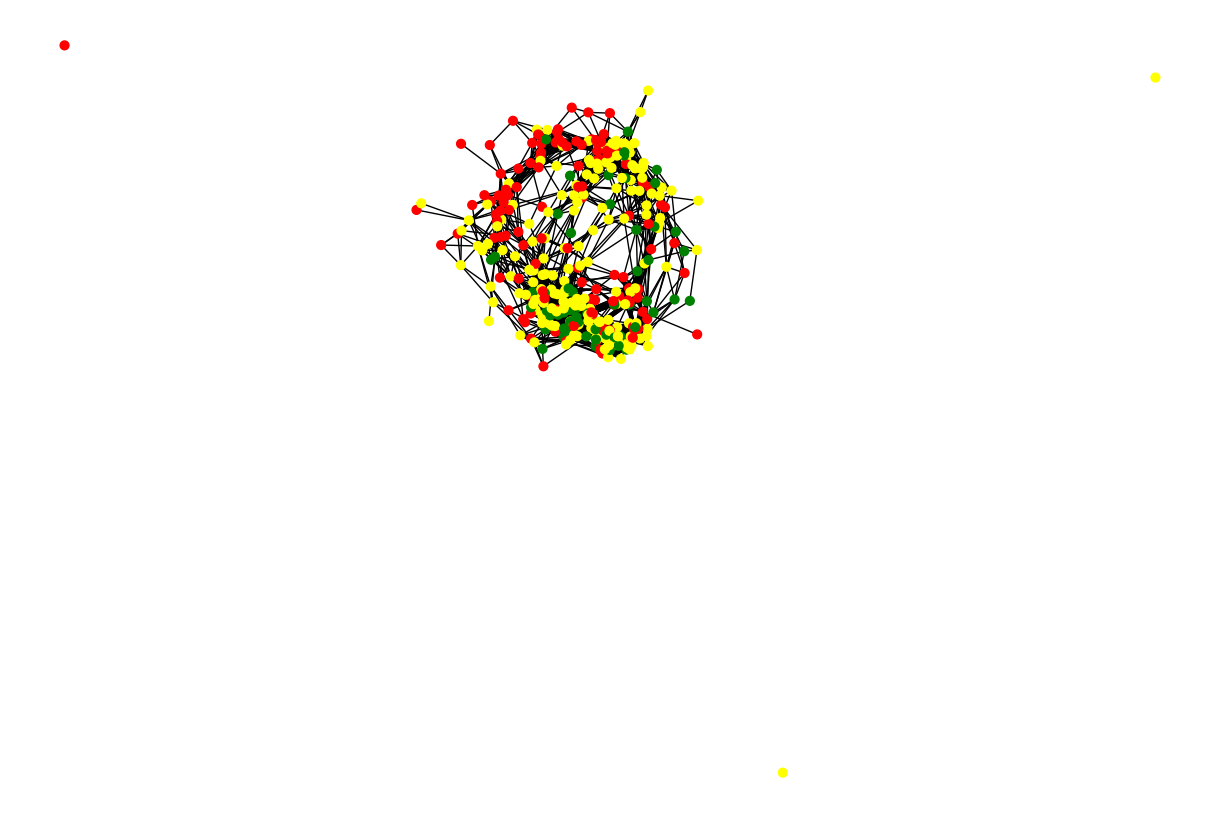

In [ ]:
plt.figure(figsize=(12,8))

nx.draw(
    G,
    node_color=cores,
    node_size=40,
    with_labels=False
)

plt.show()

In [ ]:
for i, comunidade in enumerate(comunidades[:5]):
    print(f'\nComunidade {i}')

    print(
        dados.loc[list(comunidade), 'categoria']
        .value_counts()
    )


Comunidade 0
categoria
Médio    72
Baixo    60
Alto     14
Name: count, dtype: int64

Comunidade 1
categoria
Médio    59
Baixo    38
Alto     24
Name: count, dtype: int64

Comunidade 2
categoria
Médio    37
Alto     22
Baixo    16
Name: count, dtype: int64

Comunidade 3
categoria
Médio    18
Baixo    12
Alto     10
Name: count, dtype: int64

Comunidade 4
categoria
Médio    4
Alto     3
Baixo    3
Name: count, dtype: int64


**Conclusão**
A comparação entre os grafos mostrou que a inclusão de **G1 e G2** gerou comunidades mais homogêneas e melhor separação entre alunos de baixo, médio e alto desempenho, indicando forte influência do histórico acadêmico no desempenho final.

No grafo sem **G1 e G2**, observou-se maior mistura entre as categorias, sugerindo que variáveis comportamentais como faltas, reprovações, tempo de estudo e hábitos sociais possuem relação com o desempenho, mas menor capacidade de separação quando analisadas isoladamente.

Assim, conclui-se que o histórico de notas anteriores é o principal fator na formação dos agrupamentos, enquanto variáveis comportamentais atuam como fatores complementares.

In [ ]:
#Grafo com nó por failures (reprovações)
tamanho_nos = dados['failures'] * 200 + 40

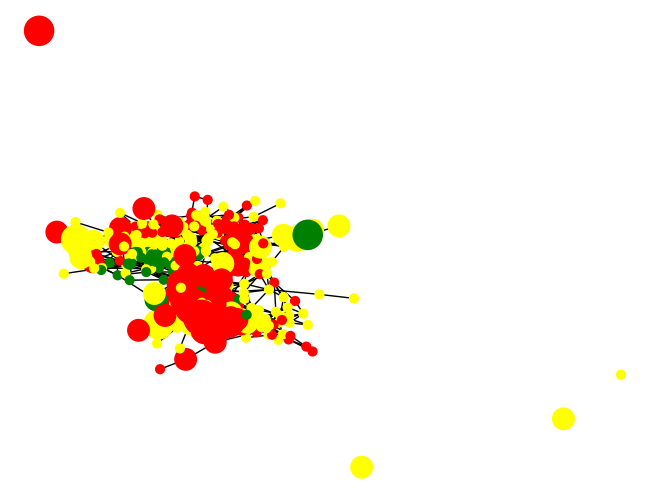

In [ ]:
nx.draw(
    G,
    node_color=cores,
    node_size=tamanho_nos,
    with_labels=False
)

In [ ]:
#Gráfico tamanho dos nós por absences (faltas)
tamanho_nos = dados['absences'] * 15 + 30

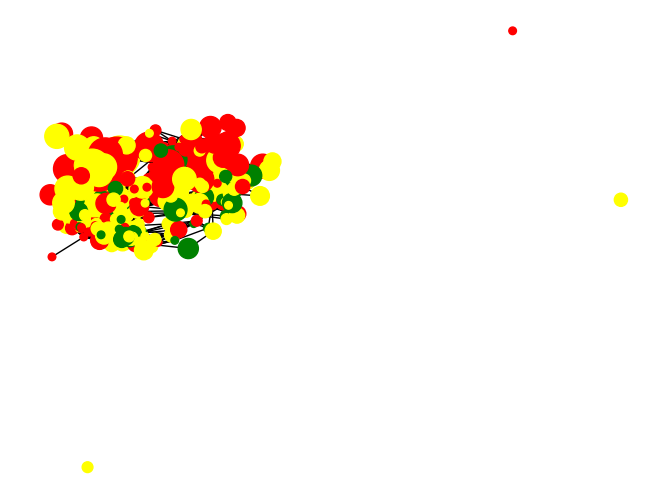

In [ ]:
nx.draw(
    G,
    node_color=cores,
    node_size=tamanho_nos,
    with_labels=False
)

In [ ]:
#calculo do grau
graus = dict(G.degree())
dados['grau'] = dados.index.map(graus)

In [ ]:
print(
    dados.groupby('categoria')['grau'].mean()
)

categoria
Alto     22.232877
Baixo    15.223077
Médio    18.135417
Name: grau, dtype: float64


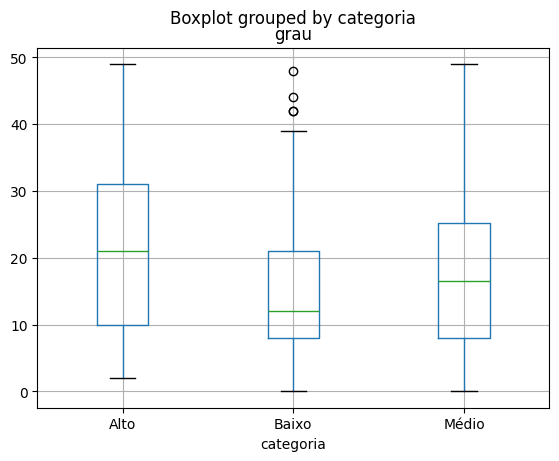

In [ ]:
dados.boxplot(column='grau', by='categoria')
plt.show()

In [ ]:
print(pd.crosstab(dados['higher'], dados['categoria']))

categoria  Alto  Baixo  Médio
higher                       
no            0     13      7
yes          73    117    185


In [ ]:
print(pd.crosstab(dados['paid'], dados['categoria']))

categoria  Alto  Baixo  Médio
paid                         
no           41     79     94
yes          32     51     98


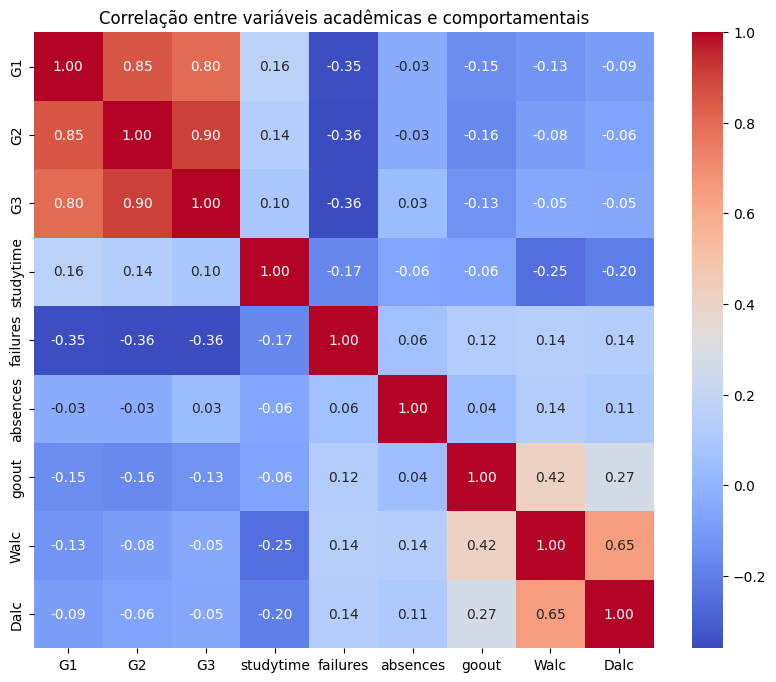

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['G1','G2','G3','studytime','failures','absences','goout','Walc','Dalc']

corr = dados[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis acadêmicas e comportamentais')
plt.show()